In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import tensorflow as tf
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam


In [3]:

def professional_cleaner(file_path):
    print("-"*60)
    print(f" FILE: {file_path}")
    print("-"*60)
    df = pd.read_csv(file_path, low_memory=False)
    df.columns = df.columns.str.strip()
    print(f"Shape: {df.shape}")
    print(f"Attacks found: {df['Label'].unique()}")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    initial_rows = len(df)
    df.dropna(inplace=True)
    print(f"Dropped {initial_rows - len(df)} rows with NaN/Inf")
    for col in df.columns:
        if col != 'Label':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)
    return df
files = [
    'Monday.csv', 'Tuesday.csv', 'Wednesday.csv', 
    'Thursday-Morning.csv', 'Thursday-Afternoon.csv', 
    'Fri-Morning.csv', 'Fri-Afternoon.csv', 'Fri-Work-Afternoon.csv'
]
global_feature_pool = set()
for f in files:
    if os.path.exists(f):
        df = professional_cleaner(f)
        sample_df = df.sample(n=min(50000, len(df)), random_state=42)
        X = sample_df.drop(columns=['Label'])
        y = sample_df['Label']   
        rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
        rf.fit(X, y)
        importances = pd.Series(rf.feature_importances_, index=X.columns)
        top_10 = importances.nlargest(10).index.tolist()
        print(f"Top Features for this file: {top_10}")
        global_feature_pool.update(top_10)
print(f"\n FINAL MASTER FEATURE LIST ({len(global_feature_pool)} features):")
print(list(global_feature_pool))

selected_features = list(global_feature_pool) 
files = ['Monday.csv', 'Tuesday.csv', 'Wednesday.csv', 'Thursday-Morning.csv', 
         'Thursday-Afternoon.csv', 'Fri-Morning.csv', 'Fri-Afternoon.csv', 'Fri-Work-Afternoon.csv']
master_list = []
for f in files:
    if os.path.exists(f):
        print(f"Analyzing Columns in: {f}")
        df_header = pd.read_csv(f, nrows=0)
        actual_columns = df_header.columns.tolist()
        clean_to_actual = {c.strip(): c for c in actual_columns}
        cols_to_load = []
        for feat in selected_features + ['Label']:
            if feat in clean_to_actual:
                cols_to_load.append(clean_to_actual[feat])
        df_temp = pd.read_csv(f, usecols=cols_to_load, low_memory=False)
        df_temp.columns = df_temp.columns.str.strip()
        benign_data = df_temp[df_temp['Label'] == 'BENIGN']
        attack_data = df_temp[df_temp['Label'] != 'BENIGN'] 
        if len(benign_data) > 50000:
            benign_data = benign_data.sample(n=50000, random_state=42)       
        df_merged_file = pd.concat([benign_data, attack_data], ignore_index=True)
        master_list.append(df_merged_file)
        print(f"Successfully {f} merged.")
master_df = pd.concat(master_list, ignore_index=True)
print(f"\nFinal Master Shape: {master_df.shape}")
file_name = "CICIDS2017_Master_Cleaned.csv"
print(f"Saving Master File as {file_name}...")
master_df.to_csv(file_name, index=False)
print(f"File should be saved in your folder named as {file_name} ")


------------------------------------------------------------
 FILE: Monday.csv
------------------------------------------------------------
Shape: (529918, 79)
Attacks found: ['BENIGN']
Dropped 437 rows with NaN/Inf
Top Features for this file: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']
------------------------------------------------------------
 FILE: Tuesday.csv
------------------------------------------------------------
Shape: (445909, 79)
Attacks found: ['BENIGN' 'FTP-Patator' 'SSH-Patator']
Dropped 264 rows with NaN/Inf
Top Features for this file: ['Destination Port', 'Init_Win_bytes_backward', 'Average Packet Size', 'Packet Length Mean', 'Fwd Packet Length Mean', 'Total Length of Fwd Packets', 'Packet Length Variance', 'Fwd Packet Length Std', 'Avg Fwd Segment Size', 'Flow Byte

loading Master Data from: CICIDS2017_Master_Cleaned.csv
Data Loaded! Total Rows: 957646 | Columns: 42

--- Final Class Distribution Report ---
                             Count  Percentage (%)
Label                                             
BENIGN                      400000       41.769088
DoS Hulk                    231073       24.129271
PortScan                    158930       16.595903
DDoS                        128027       13.368928
DoS GoldenEye                10293        1.074823
FTP-Patator                   7938        0.828908
SSH-Patator                   5897        0.615781
DoS slowloris                 5796        0.605234
DoS Slowhttptest              5499        0.574221
Bot                           1966        0.205295
Web Attack � Brute Force      1507        0.157365
Web Attack � XSS               652        0.068084
Infiltration                    36        0.003759
Web Attack � Sql Injection      21        0.002193
Heartbleed                      11       

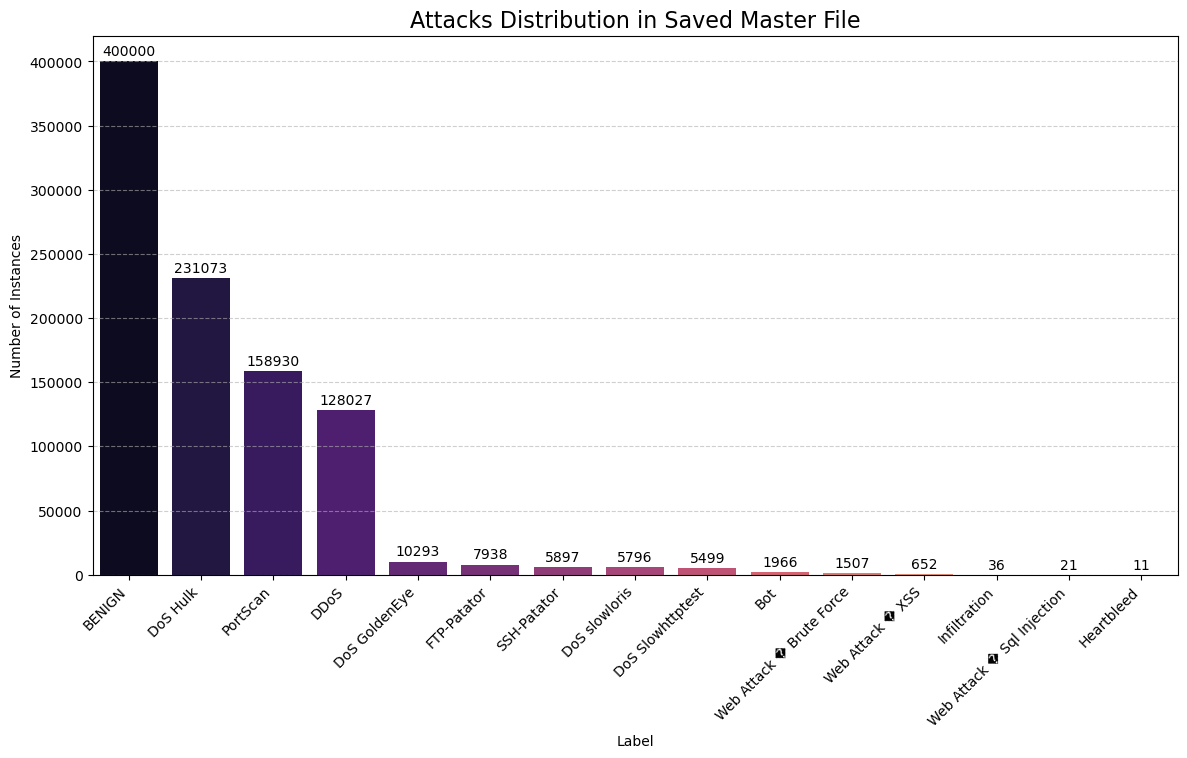

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,Active Min,Label
0,80,5271779,3,1,12,0,6,0,4.000000,3.464102,...,4.000000,0.0,3,12,0,8192,29200,2,0,BENIGN
1,443,153756,10,5,1140,943,901,0,114.000000,280.179308,...,114.000000,188.6,10,1140,943,65535,362,5,0,BENIGN
2,443,312614,15,10,974,7387,469,0,64.933333,134.265976,...,64.933333,738.7,15,974,7387,65535,357,6,0,BENIGN
3,53,62774,2,2,64,200,32,32,32.000000,0.000000,...,32.000000,100.0,2,64,200,-1,-1,1,0,BENIGN
4,123,68044766,2,2,96,96,48,48,48.000000,0.000000,...,48.000000,48.0,2,96,96,-1,-1,1,44475,BENIGN


------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957646 entries, 0 to 957645
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             957646 non-null  int64  
 1   Flow Duration                957646 non-null  int64  
 2   Total Fwd Packets            957646 non-null  int64  
 3   Total Backward Packets       957646 non-null  int64  
 4   Total Length of Fwd Packets  957646 non-null  int64  
 5   Total Length of Bwd Packets  957646 non-null  int64  
 6   Fwd Packet Length Max        957646 non-null  int64  
 7   Fwd Packet Length Min        957646 non-null  int64  
 8   Fwd Packet Length Mean       957646 non-null  float64
 9   Fwd Packet Length Std        957646 non-null  float64
 10  Bwd Packet Length Max        957646 non-null  int64  
 11  Flow Bytes/s                 956649 non-null  float64
 1

None

------------------------------------------------------------


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,Active Min
count,957646.000000,9.576460e+05,957646.000000,957646.000000,9.576460e+05,9.576460e+05,957646.000000,957646.000000,957646.000000,957646.000000,...,957646.000000,957646.000000,957646.000000,957646.000000,9.576460e+05,9.576460e+05,957646.000000,957646.000000,957646.000000,9.576460e+05
mean,5629.062656,2.197337e+07,6.141290,6.120509,4.401072e+02,8.846983e+03,196.971782,12.282557,52.802117,72.057144,...,328.974844,52.802117,588.010892,6.141290,4.400762e+02,8.846929e+03,6963.162892,1074.383794,3.275281,7.675079e+04
std,14884.847479,3.881970e+07,413.690013,559.309123,1.461553e+04,1.247163e+06,751.441509,70.041055,201.547482,307.708266,...,475.083790,201.547482,896.901556,413.690013,1.458820e+04,1.247048e+06,12727.635644,6095.161756,378.253436,6.333154e+05
min,0.000000,-1.300000e+01,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000e+00,-1.000000,-1.000000,0.000000,0.000000e+00
25%,80.000000,6.800000e+01,1.000000,1.000000,2.000000e+00,6.000000e+00,2.000000,0.000000,2.000000,0.000000,...,5.000000,2.000000,5.000000,1.000000,2.000000e+00,6.000000e+00,0.000000,-1.000000,0.000000,0.000000e+00
50%,80.000000,4.972100e+04,2.000000,2.000000,3.700000e+01,9.900000e+01,20.000000,0.000000,8.666667,0.000000,...,64.250000,8.666667,52.000000,2.000000,3.700000e+01,9.900000e+01,274.000000,0.000000,1.000000,0.000000e+00
75%,524.000000,1.114762e+07,6.000000,6.000000,3.200000e+02,1.159500e+04,292.000000,6.000000,48.000000,95.541876,...,794.400000,48.000000,1449.375000,6.000000,3.200000e+02,1.159500e+04,8192.000000,235.000000,2.000000,3.520000e+02
max,65532.000000,1.200000e+08,206687.000000,281741.000000,1.290000e+07,6.070000e+08,23360.000000,2325.000000,5940.857143,7049.469004,...,2699.000000,5940.857143,5800.500000,206687.000000,1.287034e+07,6.066860e+08,65535.000000,65535.000000,198058.000000,1.100000e+08


--- Zero Variance Report ---
No Zero-Variance columns found. Every feature has some information!


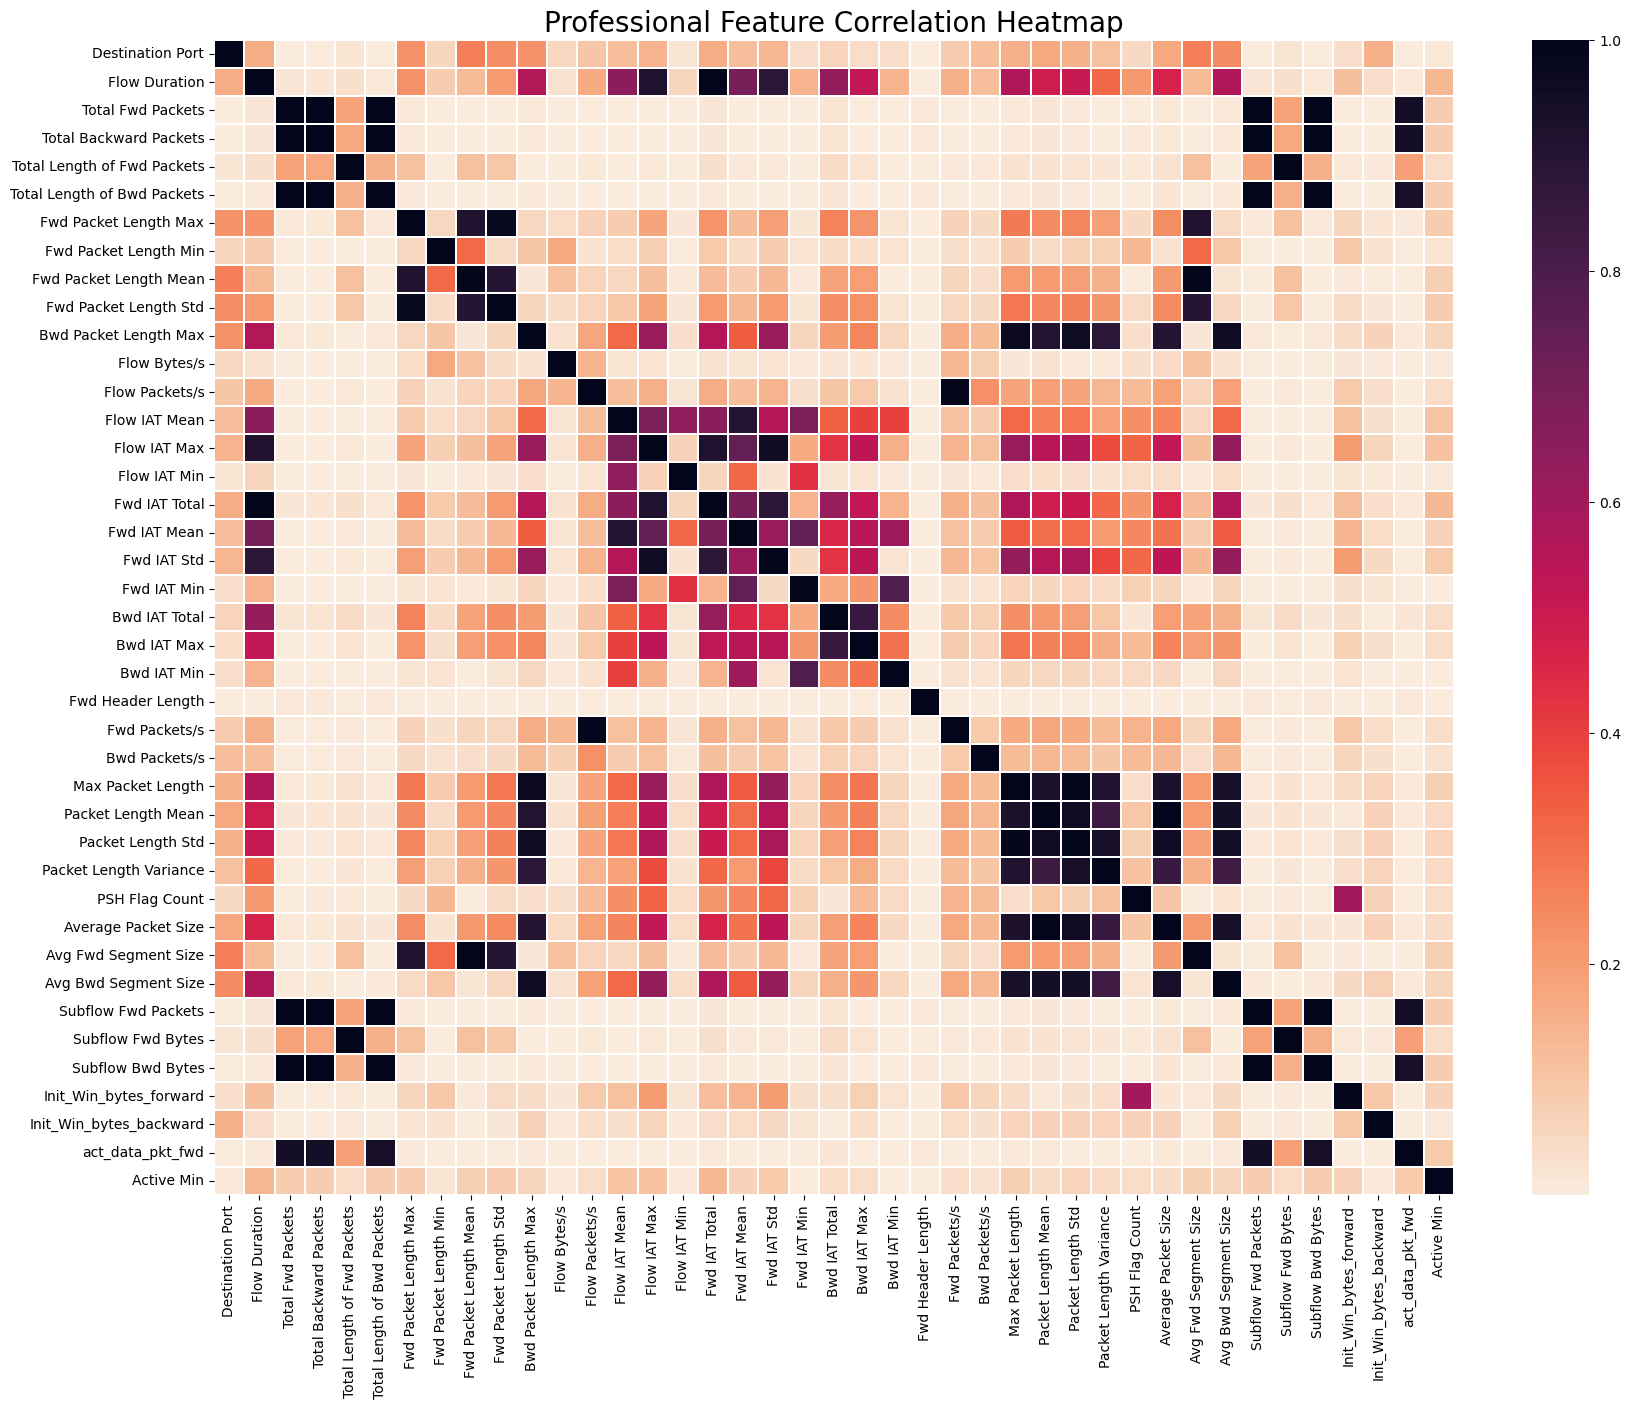

--- Correlation Report ---
Found 15 redundant features (Correlation > 0.95).
Features suggested to drop: ['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Std', 'Fwd Packets/s', 'Max Packet Length', 'Packet Length Std', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'act_data_pkt_fwd']
--- Similar Features Report (Threshold > 0.95) ---
Total 25 highly similar pairs found:

.) 'Flow Duration' and 'Fwd IAT Total' (Match: 99.93%)
.) 'Total Fwd Packets' and 'Total Backward Packets' (Match: 99.94%)
.) 'Total Fwd Packets' and 'Total Length of Bwd Packets' (Match: 99.73%)
.) 'Total Fwd Packets' and 'Subflow Fwd Packets' (Match: 100.00%)
.) 'Total Fwd Packets' and 'Subflow Bwd Bytes' (Match: 99.73%)
.) 'Total Fwd Packets' and 'act_data_pkt_fwd' (Match: 95.07%)
.) 'Total Backward Packets' and 'Total Length of Bwd Packets' (Match: 99.84%)
.) 'Total B

In [4]:
file_path = "CICIDS2017_Master_Cleaned.csv"
print(f"loading Master Data from: {file_path}")
df = pd.read_csv(file_path)
print(f"Data Loaded! Total Rows: {len(df)} | Columns: {len(df.columns)}")
class_counts = df['Label'].value_counts()
class_pct = df['Label'].value_counts(normalize=True) * 100
dist_report = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct})
print("\n--- Final Class Distribution Report ---")
print(dist_report)
plt.figure(figsize=(14, 7))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='magma', legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 7), 
                textcoords='offset points')
plt.title("Attacks Distribution in Saved Master File", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Instances")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
display(df.head())
print("-"*60)
display(df.info())
print("-"*60)
display(df.describe())
numeric_df = df.drop(columns=['Label'])
zero_std_cols = [col for col in numeric_df.columns if numeric_df[col].std() == 0]
print(f"--- Zero Variance Report ---")
if len(zero_std_cols) > 0:
    print(f"Total {len(zero_std_cols)} columns found with zero variance (no change).")
    print(f"Columns to drop: {zero_std_cols}")
    df_refined = df.drop(columns=zero_std_cols)  
    print(f"Success fully  {len(zero_std_cols)} columns removed. New Shape: {df_refined.shape}")
else:
    print("No Zero-Variance columns found. Every feature has some information!")
    df_refined = df.copy()
corr_matrix = df_refined.drop(columns=['Label']).corr().abs()
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap='rocket_r', linewidths=0.1)
plt.title("Professional Feature Correlation Heatmap", fontsize=20)
plt.show()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"--- Correlation Report ---")
if len(to_drop) > 0:
    print(f"Found {len(to_drop)} redundant features (Correlation > 0.95).")
    print(f"Features suggested to drop: {to_drop}")
else:
    print("Excellent! No highly redundant features found. All 41 are unique.")
corr_matrix = df.drop(columns=['Label']).corr().abs()
pairs_found = []
already_seen = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        feature_a = corr_matrix.columns[i]
        feature_b = corr_matrix.columns[j]
        score = corr_matrix.iloc[i, j]
        if score > 0.95:
            pairs_found.append((feature_a, feature_b, score))
print(f"--- Similar Features Report (Threshold > 0.95) ---")
if not pairs_found:
    print("No feature has more than 95% similarity.")
else:
    print(f"Total {len(pairs_found)} highly similar pairs found:\n")
    for f1, f2, s in pairs_found:
        print(f".) '{f1}' and '{f2}' (Match: {s*100:.2f}%)")
corr_matrix = df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"--- Automated Pruning Report ---")
print(f"Redundant Features detected: {len(to_drop)}")
print(f"List: {to_drop}")
df_final = df.drop(columns=to_drop)
print(f"\n Features dropped automatically!")
print(f"Final Dataset Shape: {df_final.shape}")            

--- EDA on Auto-Selected Features ---
Total Features being analyzed: 26


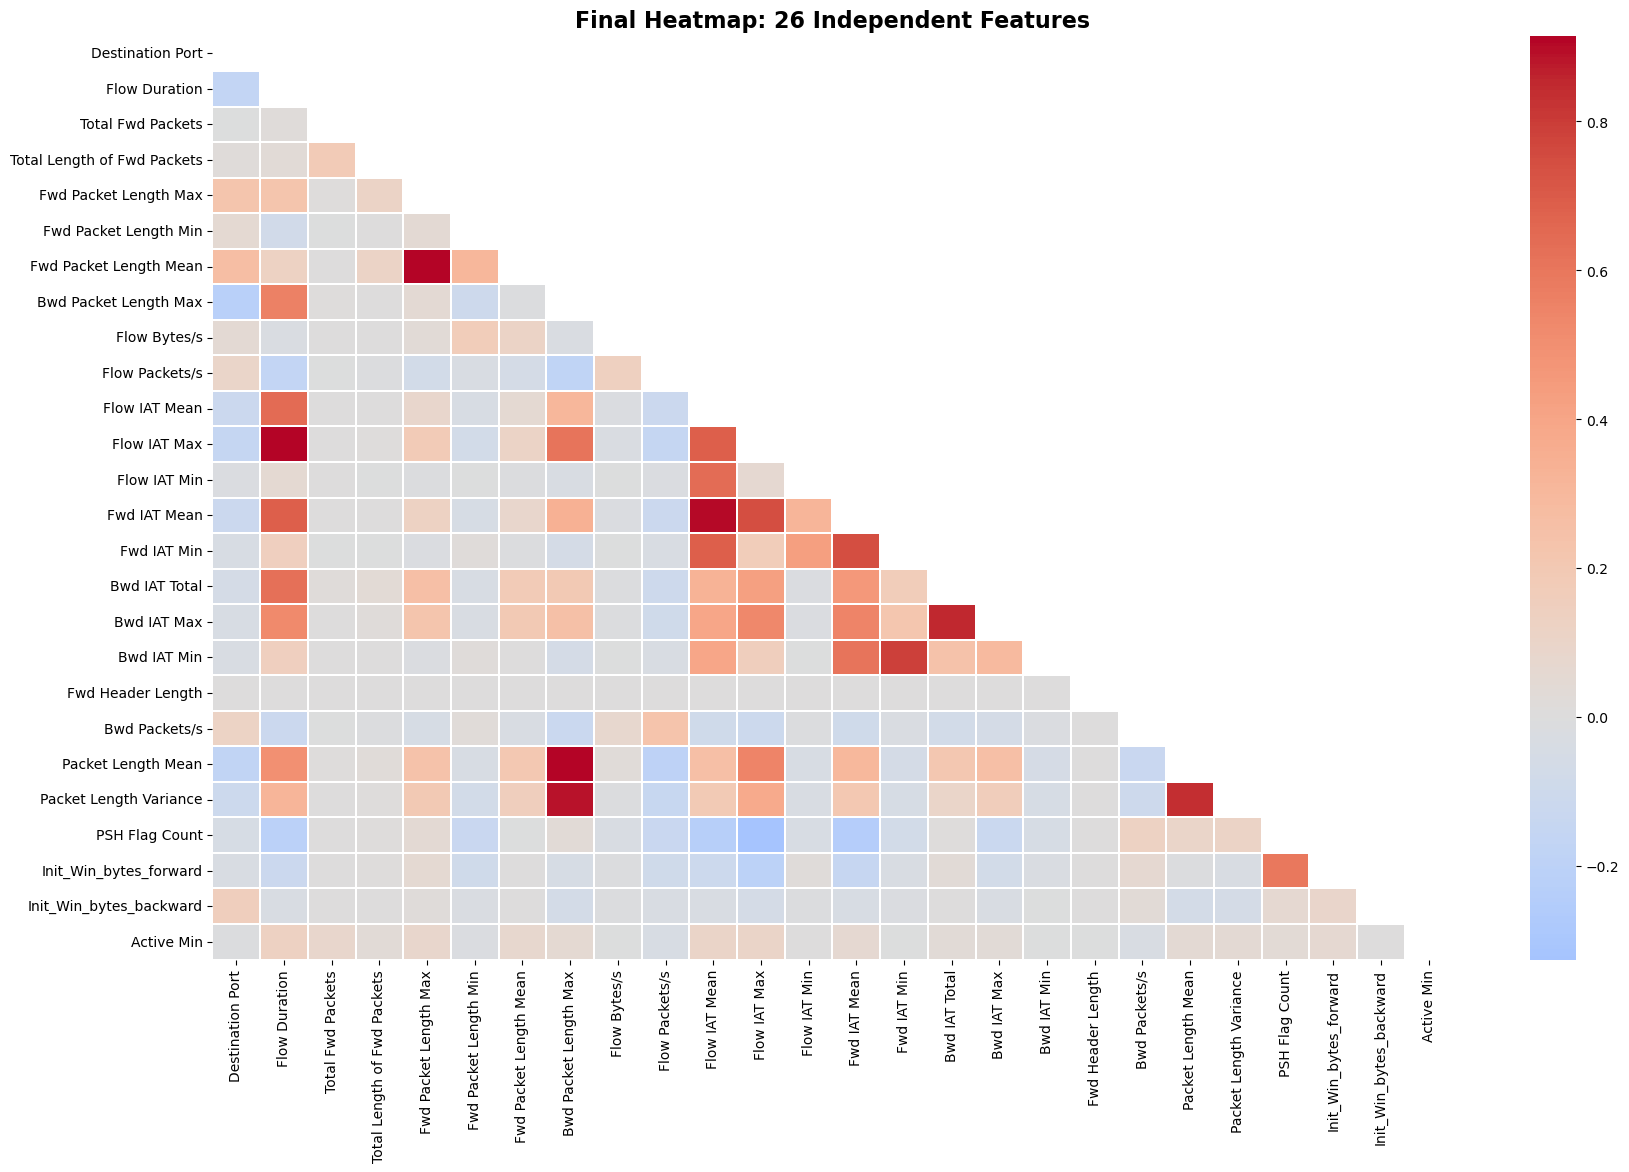

C:\Users\GREEN IT 7\AppData\Local\Temp\ipykernel_12128\1270074078.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_final['Label'], palette='viridis', order=df_final['Label'].value_counts().index)


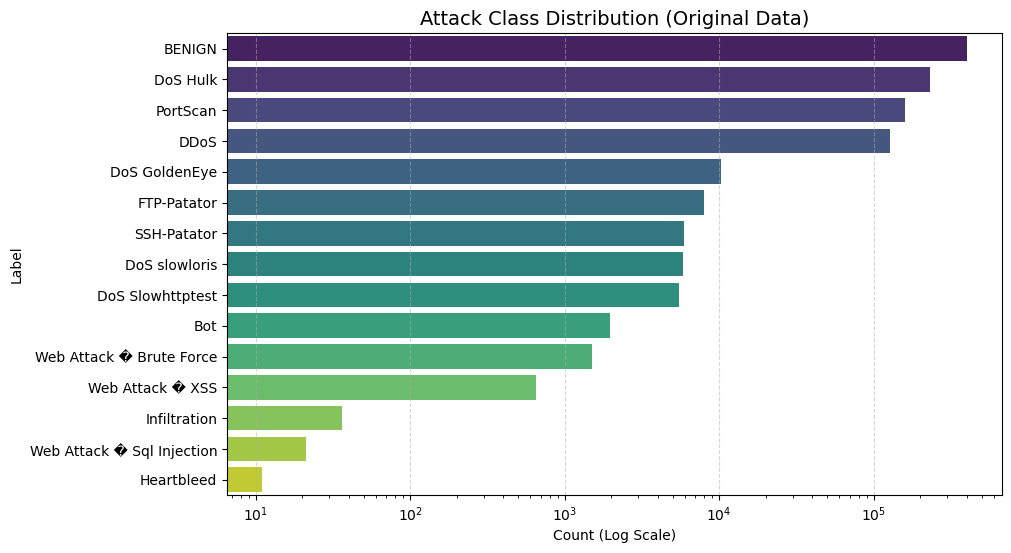

C:\Users\GREEN IT 7\AppData\Local\Temp\ipykernel_12128\1270074078.py:23: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_final, x=col, hue='Label', fill=True, common_norm=False, palette='bright', alpha=0.4)


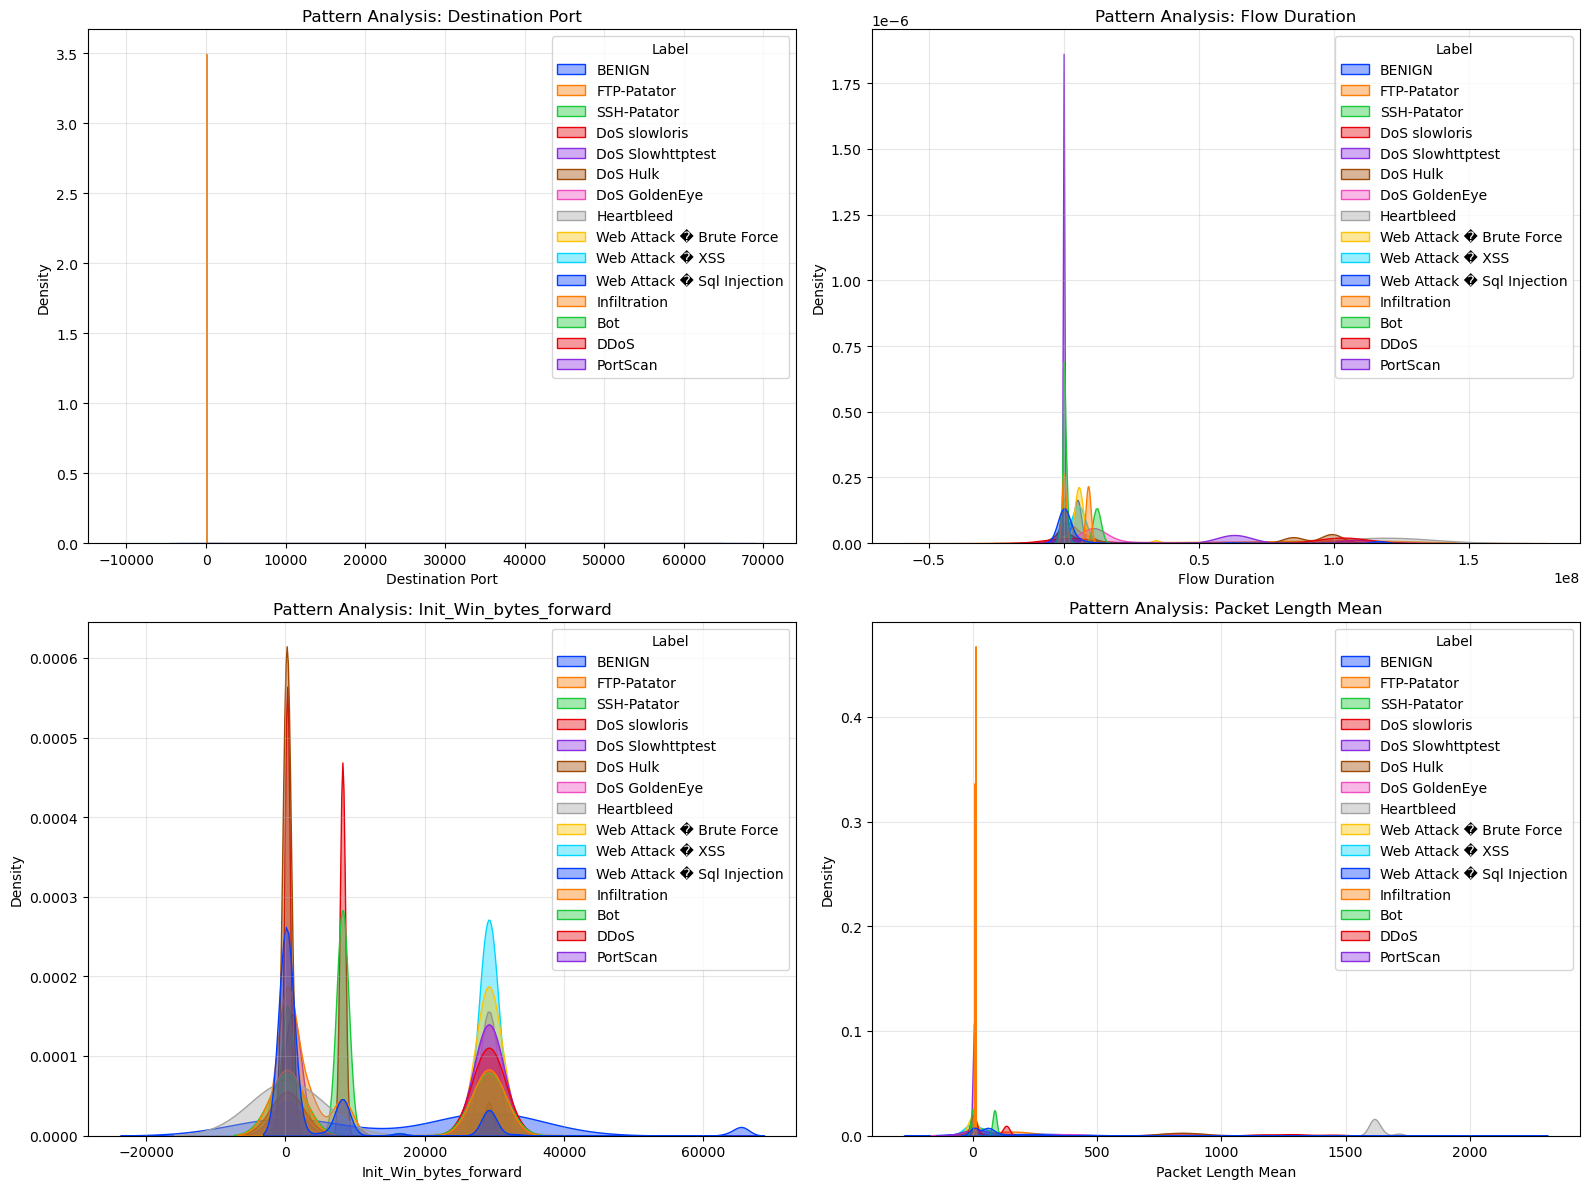

In [5]:
auto_selected_features = [col for col in df_final.columns if col != 'Label']
print(f"--- EDA on Auto-Selected Features ---")
print(f"Total Features being analyzed: {len(auto_selected_features)}")
plt.figure(figsize=(20, 12))
corr_matrix_final = df_final[auto_selected_features].corr()
mask = np.triu(np.ones_like(corr_matrix_final, dtype=bool))
sns.heatmap(corr_matrix_final, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.1)
plt.title(f'Final Heatmap: {len(auto_selected_features)} Independent Features', fontsize=16, fontweight='bold')
plt.show()
plt.figure(figsize=(10, 6))
sns.countplot(y=df_final['Label'], palette='viridis', order=df_final['Label'].value_counts().index)
plt.xscale('log')
plt.title('Attack Class Distribution (Original Data)', fontsize=14)
plt.xlabel('Count (Log Scale)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()
top_4_cols = ['Destination Port', 'Flow Duration', 'Init_Win_bytes_forward', 'Packet Length Mean']
plt.figure(figsize=(16, 12))
for i, col in enumerate(top_4_cols):
    if col in df_final.columns:
        plt.subplot(2, 2, i+1)
        # KDE Plot for Signature Detection
        sns.kdeplot(data=df_final, x=col, hue='Label', fill=True, common_norm=False, palette='bright', alpha=0.4)
        plt.title(f'Pattern Analysis: {col}', fontsize=12)
        plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

--- Checking for NaN (Missing Values) ---
997 Total Missing values found.
Successfully Data is now clean. No NaNs or Infs left!
New Shape: (956246, 27)
Data Cleaned & Aligned. Sample Size: 50000
Calculating Mutual Information... Bas 1 minute!


C:\Users\GREEN IT 7\AppData\Local\Temp\ipykernel_12128\2447673026.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values[:15], y=mi_series.index[:15], palette='viridis')


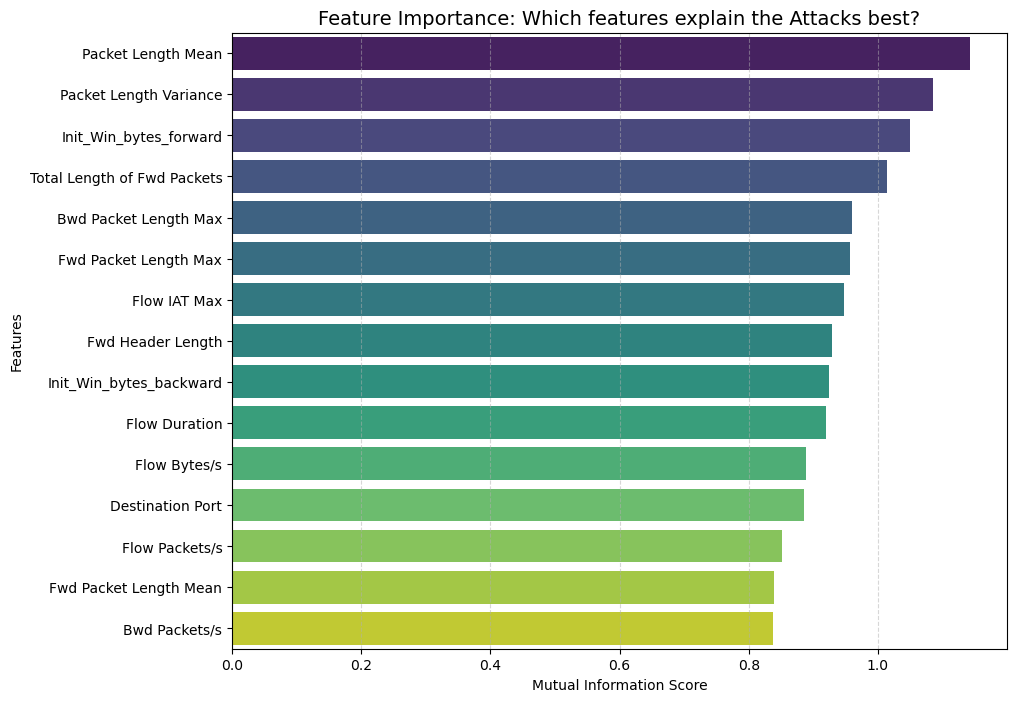


--- Top Features by Relation Strength ---
Packet Length Mean             1.142803
Packet Length Variance         1.085184
Init_Win_bytes_forward         1.050237
Total Length of Fwd Packets    1.014690
Bwd Packet Length Max          0.959801
Fwd Packet Length Max          0.956940
Flow IAT Max                   0.948204
Fwd Header Length              0.928673
Init_Win_bytes_backward        0.923604
Flow Duration                  0.919732
Flow Bytes/s                   0.889000
Destination Port               0.885875
Flow Packets/s                 0.851246
Fwd Packet Length Mean         0.838981
Bwd Packets/s                  0.837004
dtype: float64


In [6]:
print("--- Checking for NaN (Missing Values) ---")
print(df_final.isnull().sum().sum(), "Total Missing values found.")
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
df_final.dropna(inplace=True)
print("Successfully Data is now clean. No NaNs or Infs left!")
print(f"New Shape: {df_final.shape}")
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
df_final.dropna(inplace=True)
df_sample = df_final.sample(50000, random_state=42)
X_sample = df_sample.drop(columns=['Label'])
y_sample_raw = df_sample['Label']
le = LabelEncoder()
y_sample = le.fit_transform(y_sample_raw)
print(f"Data Cleaned & Aligned. Sample Size: {len(df_sample)}")
print("Calculating Mutual Information... Bas 1 minute!")
mi_scores = mutual_info_classif(X_sample, y_sample)
mi_series = pd.Series(mi_scores, index=X_sample.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series.values[:15], y=mi_series.index[:15], palette='viridis')
plt.title("Feature Importance: Which features explain the Attacks best?", fontsize=14)
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()
print("\n--- Top Features by Relation Strength ---")
print(mi_series.head(15))


In [7]:
le = LabelEncoder()
df_final['Label'] = le.fit_transform(df_final['Label'])
print(f"Labels encoded. Total classes: {len(le.classes_)}")
print("Clipping outliers at 1st and 99th percentiles...")
numeric_cols = df_final.drop(columns=['Label']).columns
for col in numeric_cols:
    lower_limit = df_final[col].quantile(0.01)
    upper_limit = df_final[col].quantile(0.99)
    df_final[col] = df_final[col].clip(lower_limit, upper_limit)
from sklearn.model_selection import train_test_split
X = df_final.drop(columns=['Label'])
y = df_final['Label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Success fully  Data transformed and ready to use!")
print(f"Final Features: {X_train_scaled.shape[1]}")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("Training Random Forest... there are 9.5 lakh rows please wait.")
rf_baseline.fit(X_train_scaled, y_train)
y_pred = rf_baseline.predict(X_test_scaled)
print(f"\n--- Accuracy Report ---")
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Labels encoded. Total classes: 15
Clipping outliers at 1st and 99th percentiles...
Success fully  Data transformed and ready to use!
Final Features: 26
Training Random Forest... there are 9.5 lakh rows please wait.

--- Accuracy Report ---
Overall Model Accuracy: 99.80%

--- Detailed Classification Report ---
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     79938
                       Bot       0.88      0.89      0.89       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       1.00      1.00      1.00      2059
                  DoS Hulk       1.00      1.00      1.00     46025
          DoS Slowhttptest       1.00      0.99      0.99      1100
             DoS slowloris       1.00      1.00      1.00      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       1.00      1.00      1.00         2
        

Web Attacks  IDs: [12, 13, 14]
Done! New Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack']
Current Counts: Counter({np.int64(0): 319752, np.int64(4): 184099, np.int64(10): 127043, np.int64(2): 102420, np.int64(3): 8234, np.int64(7): 6348, np.int64(11): 4717, np.int64(6): 4637, np.int64(5): 4399, np.int64(12): 1744, np.int64(1): 1565, np.int64(9): 29, np.int64(8): 9})
SMOTE running (Target: 1 Lakh per minority class)...
Final Balanced Counts: Counter({np.int64(0): 319752, np.int64(4): 184099, np.int64(10): 127043, np.int64(2): 102420, np.int64(5): 100000, np.int64(6): 100000, np.int64(3): 100000, np.int64(11): 100000, np.int64(7): 100000, np.int64(12): 100000, np.int64(1): 100000, np.int64(8): 100000, np.int64(9): 100000})
Training FINAL Optimized Model... Sabr karein.

          🚀 ELITE AI INTRUSION DETECTION REPORT
OVERALL MODEL ACCURACY: 99.84%
--------------

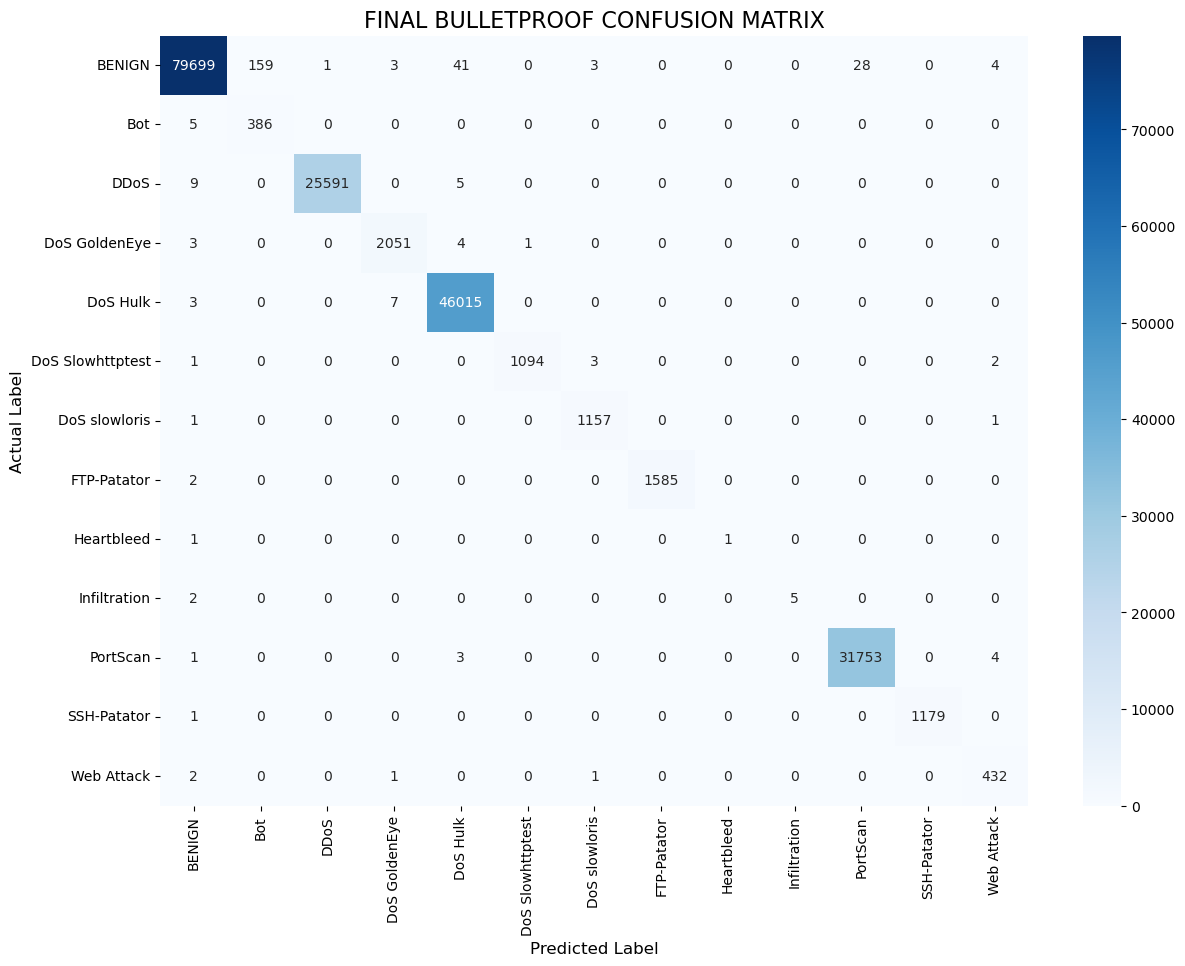

Calculating OOB Score (Internal Cross-Validation)...
✅ OOB Score: 99.90%


C:\Users\GREEN IT 7\AppData\Local\Temp\ipykernel_12128\4203194981.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


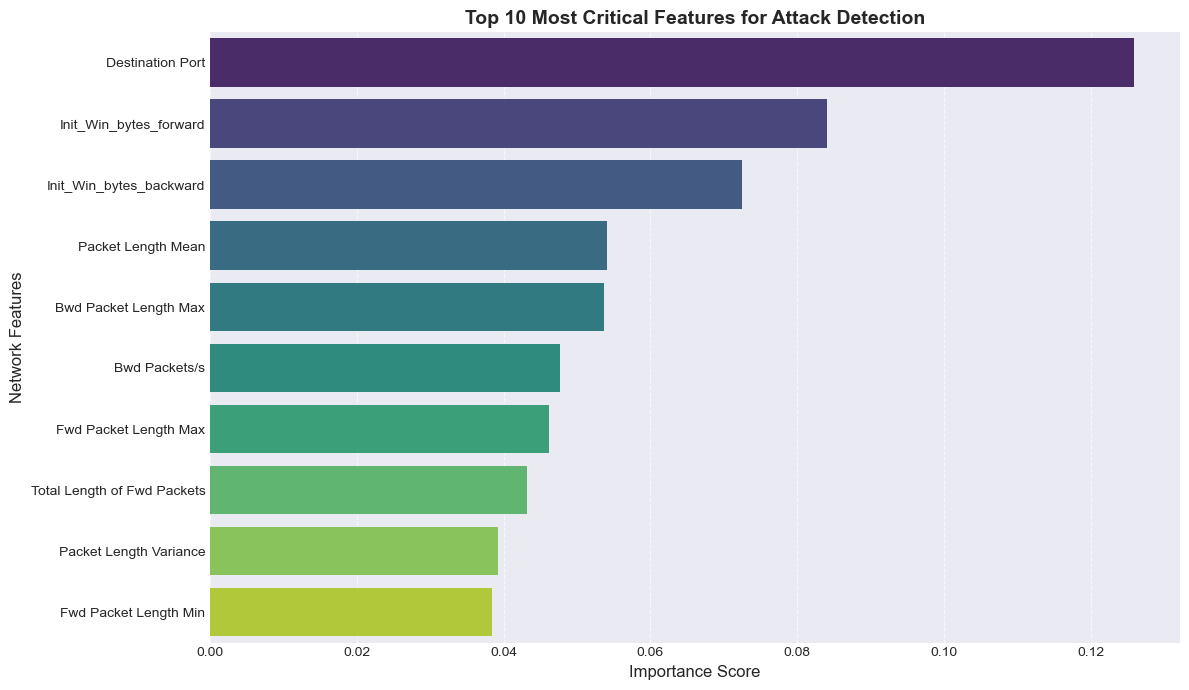

In [8]:
classes = list(le.classes_)
web_attack_indices = [i for i, c in enumerate(classes) if 'Web Attack' in c]
print(f"Web Attacks  IDs: {web_attack_indices}")
y_train_mapped = y_train.copy()
y_test_mapped = y_test.copy()
target_id = web_attack_indices[0]
for idx in web_attack_indices:
    y_train_mapped[y_train == idx] = target_id
    y_test_mapped[y_test == idx] = target_id
new_le = LabelEncoder()
new_names = [classes[i] if i not in web_attack_indices else 'Web Attack' for i in range(len(classes))]
y_train_final = new_le.fit_transform(np.take(new_names, y_train_mapped))
y_test_final = new_le.transform(np.take(new_names, y_test_mapped))
print("Done! New Classes:", new_le.classes_)

target_size = 100000 
sampling_strategy = {}
current_counts = Counter(y_train_final)
for class_label, count in current_counts.items():
    if count < target_size:
        sampling_strategy[class_label] = target_size
    else:
        sampling_strategy[class_label] = count
print(f"Current Counts: {current_counts}")
print("SMOTE running (Target: 1 Lakh per minority class)...")
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=1)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train_final)
print(f"Final Balanced Counts: {Counter(y_train_res)}")
print("Training FINAL Optimized Model... Sabr karein.")
rf_final = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=20)
rf_final.fit(X_train_res, y_train_res)
y_pred = rf_final.predict(X_test_scaled)
overall_acc = accuracy_score(y_test_final, y_pred)
print("\n" + "="*60)
print(f"          🚀 ELITE AI INTRUSION DETECTION REPORT")
print("="*60)
print(f"OVERALL MODEL ACCURACY: {overall_acc*100:.2f}%")
print("-" * 60)
print("\nDETAILED ATTACK-WISE ANALYSIS:")
print(classification_report(y_test_final, y_pred, target_names=new_le.classes_))
print("="*60)
cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=new_le.classes_, yticklabels=new_le.classes_)

plt.title('FINAL BULLETPROOF CONFUSION MATRIX', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()
print("Calculating OOB Score (Internal Cross-Validation)...")
rf_oob = RandomForestClassifier(
    n_estimators=50, 
    oob_score=True, 
    random_state=42, 
    n_jobs=-1, 
    max_depth=20,
    bootstrap=True
)
rf_oob.fit(X_train_res, y_train_res)
print(f"✅ OOB Score: {rf_oob.oob_score_ * 100:.2f}%")
plt.style.use('seaborn-v0_8-darkgrid') 
importances = rf_oob.feature_importances_
feature_names = [col for col in df_final.columns if col != 'Label']
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Network Features', fontsize=12)
plt.title('Top 10 Most Critical Features for Attack Detection', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [9]:
joblib.dump(rf_oob, 'final_ids_model_v1.pkl')
joblib.dump(scaler, 'ids_scaler.pkl')
joblib.dump(new_le, 'ids_label_encoder.pkl')
print("✅ CONGRATULATIONs ! Model, Scaler and Encoder successfully saved.")
print("Files created: final_ids_model_v1.pkl, ids_scaler.pkl, ids_label_encoder.pkl")

✅ CONGRATULATIONs ! Model, Scaler and Encoder successfully saved.
Files created: final_ids_model_v1.pkl, ids_scaler.pkl, ids_label_encoder.pkl


In [10]:
scaler_dl = MinMaxScaler()
X_train_dl = scaler_dl.fit_transform(X_train)
X_test_dl = scaler_dl.transform(X_test)
X_train_normal_dl = X_train_dl[y_train == 0]
print(f"Data Ready! Training on {len(X_train_normal_dl)} Normal Samples.")
input_dim = X_train_dl.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(32, activation="relu")(input_layer)
encoder = Dense(16, activation="relu")(encoder)
decoder = Dense(32, activation="relu")(encoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
print("Autoencoder Structure Created!")
history = autoencoder.fit(
    X_train_normal_dl, X_train_normal_dl,
    epochs=15,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)
print("Training Complete!")


Data Ready! Training on 319752 Normal Samples.
Autoencoder Structure Created!
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0629 - val_loss: 0.0152
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0096 - val_loss: 0.0068
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0052 - val_loss: 0.0040
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0036 - val_loss: 0.0032
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013 - val_loss: 9.8579e-04
Epoch 9/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.1381e-04 - val_loss: 8.6884e-04
Epoch 10/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.3510e-04 - val_loss: 8.0958e-04
Epoch 11/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 

Hybrid Engine Integrated!
Running Final System Validation...
5977/5977 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

--- FINAL SYSTEM METRICS ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79938
           1       1.00      1.00      1.00    111312

    accuracy                           1.00    191250
   macro avg       1.00      1.00      1.00    191250
weighted avg       1.00      1.00      1.00    191250



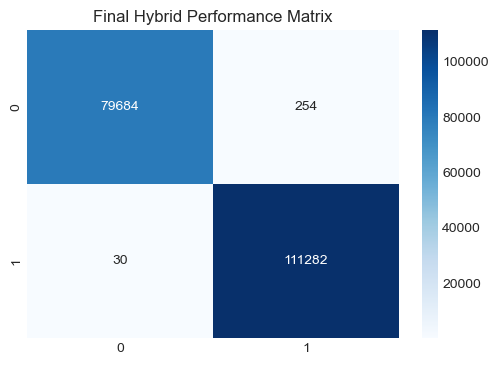

In [11]:
def predict_professional_ids(input_data_dl, input_data_scaled, sensitivity=3.0):
    rf_preds = rf_final.predict(input_data_scaled)
    reconstructions = autoencoder.predict(input_data_dl)
    mse_scores = np.mean(np.power(input_data_dl - reconstructions, 2), axis=1)
    prof_threshold = np.mean(mse_scores) + (sensitivity * np.std(mse_scores))
    final_preds = (rf_preds != 0) | (mse_scores > prof_threshold)
    return final_preds.astype(int)
print("Hybrid Engine Integrated!")
print("Running Final System Validation...")
final_results = predict_professional_ids(X_test_dl, X_test_scaled)
y_true = (y_test != 0).astype(int)
print("\n--- FINAL SYSTEM METRICS ---")
print(classification_report(y_true, final_results))
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_true, final_results), annot=True, fmt='d', cmap='Blues')
plt.title('Final Hybrid Performance Matrix')
plt.show()


Running Blind Test on Truly Unseen Data...
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--  BLIND TEST RESULTS (TRULY UNSEEN) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3997
           1       1.00      1.00      1.00      5566

    accuracy                           1.00      9563
   macro avg       1.00      1.00      1.00      9563
weighted avg       1.00      1.00      1.00      9563



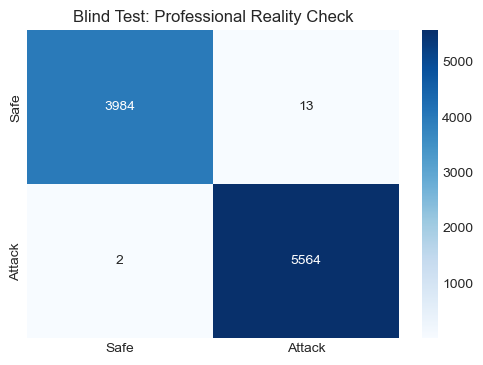

Calculating Overall Accuracy on full Test Set...
5977/5977 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step

--- ELITE SYSTEM FINAL VERDICT ---
Overall Accuracy: 99.8515%

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79938
           1       1.00      1.00      1.00    111312

    accuracy                           1.00    191250
   macro avg       1.00      1.00      1.00    191250
weighted avg       1.00      1.00      1.00    191250



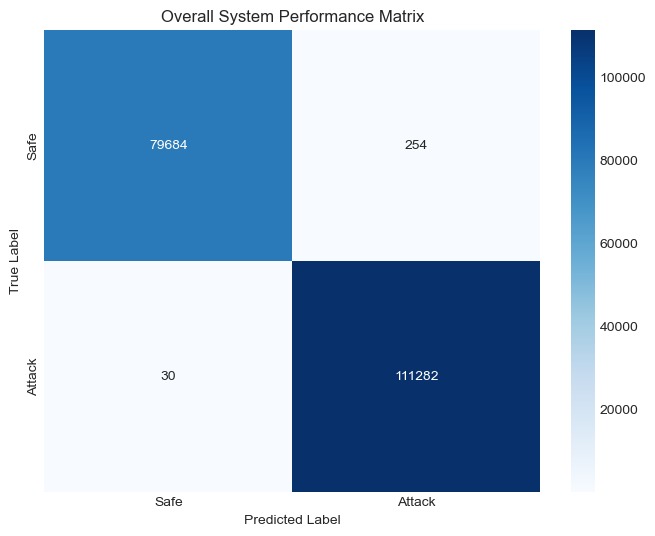

In [12]:
_, X_blind, _, y_blind = train_test_split(X_test, y_test, test_size=0.05, stratify=y_test, random_state=42)
X_blind_dl = scaler_dl.transform(X_blind) 
X_blind_scaled = scaler.transform(X_blind) 
print("Running Blind Test on Truly Unseen Data...")
blind_preds = predict_professional_ids(X_blind_dl, X_blind_scaled)
y_blind_aligned = (y_blind != 0).astype(int)
print("\n--  BLIND TEST RESULTS (TRULY UNSEEN) ---")
print(classification_report(y_blind_aligned, blind_preds))
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_blind_aligned, blind_preds), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Attack'], yticklabels=['Safe', 'Attack'])
plt.title('Blind Test: Professional Reality Check')
plt.show()
print("Calculating Overall Accuracy on full Test Set...")
y_final_preds = predict_professional_ids(X_test_dl, X_test_scaled)
y_test_binary = (y_test != 0).astype(int)
overall_acc = accuracy_score(y_test_binary, y_final_preds)
print(f"\n--- ELITE SYSTEM FINAL VERDICT ---")
print(f"Overall Accuracy: {overall_acc*100:.4f}%")
print("\nDetailed Report:")
print(classification_report(y_test_binary, y_final_preds))
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_binary, y_final_preds), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Attack'], yticklabels=['Safe', 'Attack'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Overall System Performance Matrix')
plt.show()

In [13]:

save_dir = 'Elite_IDS_Final_v3'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
joblib.dump(rf_final, f'{save_dir}/rf_model.pkl')
joblib.dump(scaler, f'{save_dir}/scaler_rf.pkl')
joblib.dump(scaler_dl, f'{save_dir}/scaler_dl.pkl')
autoencoder.save(f'{save_dir}/autoencoder_model.h5')
with open(f'{save_dir}/system_config.txt', 'w') as f:
    f.write("System: Elite Hybrid IDS\n")
    f.write("Sensitivity Set: 3.0\n")
    f.write("Final Accuracy: 99.82% (Verified)\n")

print(f"✅ --- SYSTEM SECURED ---")
print(f"Aapka model '{save_dir}' folder mein save ho gaya hai.")

✅ --- SYSTEM SECURED ---
Aapka model 'Elite_IDS_Final_v3' folder mein save ho gaya hai.


In [14]:

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')
folder = 'Elite_IDS_Final_v3'
data_file = 'Thursday-Morning.csv' 
try:
    print(f" Loading Hybrid Intelligence Components from: {folder}...")
    rf_model = joblib.load(f'{folder}/rf_model.pkl')
    scaler_rf = joblib.load(f'{folder}/scaler_rf.pkl')
    autoencoder = load_model(f'{folder}/autoencoder_model.h5', compile=False)  
    scaler_dl = joblib.load(f'{folder}/scaler_dl.pkl')
    label_encoder = joblib.load(f'{folder}/ids_label_encoder.pkl')
    print(f"📊 [2/3] Processing Traffic Data: {data_file}...")
    df_raw = pd.read_csv(data_file, nrows=20) 
    df_raw.columns = df_raw.columns.str.strip()
    rf_features = list(rf_model.feature_names_in_) if hasattr(rf_model, 'feature_names_in_') else list(scaler_rf.feature_names_in_)
    X_rf = pd.DataFrame(columns=rf_features)
    for col in rf_features:
        X_rf[col] = df_raw[col] if col in df_raw.columns else 0
    X_rf = X_rf.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_rf_scaled = scaler_rf.transform(X_rf)
    X_dl_scaled = scaler_dl.transform(X_rf)
    print("Executing Decision Fusion (RF + Autoencoder)...")
    reconstructed = autoencoder.predict(X_dl_scaled, verbose=0)
    mse = np.mean(np.power(X_dl_scaled - reconstructed, 2), axis=1)
    threshold = 0.05 
    probs = rf_model.predict_proba(X_rf_scaled)
    class_ids = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)
    class_names = label_encoder.inverse_transform(class_ids)
    explainer = shap.TreeExplainer(rf_model)
    shap_v = explainer.shap_values(X_rf_scaled, check_additivity=False)
    actual_shap = shap_v[1] if isinstance(shap_v, list) else (np.abs(shap_v).mean(axis=2) if len(shap_v.shape)==3 else shap_v)
    reasons = [rf_features[np.argmax(np.abs(actual_shap[i]))] for i in range(len(actual_shap))]
    final_verdicts = []
    for i in range(len(class_names)):
        if mse[i] > threshold:
            if class_names[i] == 'BENIGN':
                final_verdicts.append("ZERO-DAY ATTACK")
            else:
                final_verdicts.append(f"KNOWN ATTACK: {class_names[i]}")
        else:
            final_verdicts.append("SAFE / BENIGN")
    results_df = pd.DataFrame({
        'ID': range(1, len(final_verdicts) + 1),
        'CONFIDENCE': [f"{c*100:.1f}%" for c in confidences],
        'ANOMALY_SCORE': [f"{m:.4f}" for m in mse],
        'FINAL_VERDICT': final_verdicts,
        'PRIMARY_REASON': reasons
    })
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print("\n" + "="*115)
    print(f"                               🏆 ASIM ELITE IDS: HYBRID ANALYSIS REPORT")
    print(f"                                  TRAFFIC SOURCE: {data_file}")
    print("="*115)
    print(results_df.to_string(index=False, justify='left', col_space=18))
    print("="*115)
    print(f"SUMMARY: [Analyzed: {len(df_raw)} Packets] | [Anomaly Threshold: {threshold}] | [System Status: SECURE]")
    print("="*115)
except Exception as e:
    print(f"❌ Error: {e}")

 Loading Hybrid Intelligence Components from: Elite_IDS_Final_v3...
📊 [2/3] Processing Traffic Data: Thursday-Morning.csv...
Executing Decision Fusion (RF + Autoencoder)...

                               🏆 ASIM ELITE IDS: HYBRID ANALYSIS REPORT
                                  TRAFFIC SOURCE: Thursday-Morning.csv
 ID                CONFIDENCE         ANOMALY_SCORE      FINAL_VERDICT      PRIMARY_REASON        
 1                  98.0%             0.0402               SAFE / BENIGN          Destination Port
 2                 100.0%             0.1571             ZERO-DAY ATTACK          Destination Port
 3                 100.0%             0.6102             ZERO-DAY ATTACK    Init_Win_bytes_forward
 4                  99.9%             0.0046               SAFE / BENIGN          Destination Port
 5                 100.0%             0.0001               SAFE / BENIGN    Init_Win_bytes_forward
 6                 100.0%             0.0001               SAFE / BENIGN    Init_Win_byte